# 13-liver-data-loading

In [1]:
import scanpy as sc
import scirpy as ir
import numpy as np
import json
from pathlib import Path
import pandas as pd
import muon as mu
import anndata as ad
import re
import warnings
warnings.filterwarnings('ignore')
from data.cell_type import annotate_cells

DATA = Path("data")

/Users/alegator1209/micromamba/envs/pytcr/lib/python3.12/site-packages/h5py/__init__.py:36: UserWarning: h5py is running against HDF5 2.2.0 when it was built against 2.1.0, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "
Matplotlib is building the font cache; this may take a moment.
/Users/alegator1209/micromamba/envs/pytcr/lib/python3.12/site-packages/muon/_core/preproc.py:32: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if Version(scanpy.__version__) < Version("1.10"):


In [2]:
def read_vdj(path: Path):
  adata = ir.io.read_10x_vdj(path)
  ir.pp.index_chains(adata)
  ir.tl.chain_qc(adata)
  return adata

def read_sample(path: Path) -> tuple[ad.AnnData, ad.AnnData, ad.AnnData]:
  mtx = next(path.glob("*_GEX_matrix.mtx.gz"))
  prefix = mtx.name[: -len("matrix.mtx.gz")]

  adata_gex = sc.read_10x_mtx(path, var_names="gene_symbols", prefix=prefix)
  adata_gex.var_names_make_unique()
  sc.pp.filter_cells(adata_gex, min_genes=200)
  sc.pp.filter_genes(adata_gex, min_cells=3)
  adata_gex.var["mt"] = adata_gex.var_names.str.startswith("MT-")
  sc.pp.calculate_qc_metrics(adata_gex, qc_vars=["mt"], inplace=True, log1p=True)
  mu.pp.filter_obs(adata_gex, 'pct_counts_mt', lambda x: x < 10)

  adata_tcr = read_vdj(next(path.glob("*_TCR_filtered_contig_annotations.csv.gz")))
  mu.pp.filter_obs(adata_tcr, "receptor_subtype", lambda x: ~np.isin(x, ["multichain", "ambiguous", "no IR"]))
  mu.pp.filter_obs(adata_tcr, "chain_pairing", lambda x: x == "single pair")

  adata_bcr = read_vdj(next(path.glob("*_BCR_filtered_contig_annotations.csv.gz")))
  mu.pp.filter_obs(adata_bcr, "receptor_subtype", lambda x: ~np.isin(x, ["multichain", "ambiguous", "no IR"]))
  mu.pp.filter_obs(adata_bcr, "chain_pairing", lambda x: x == "single pair")

  return adata_gex, adata_tcr, adata_bcr


In [3]:
SAMPLE_RE = re.compile(r"Patient(\d+)-(.+)")

adatas_gex = {}
adatas_tcr = {}
adatas_bcr = {}

for sample_dir in sorted(DATA.glob("*/*")):
  if not sample_dir.is_dir():
    continue

  match = SAMPLE_RE.fullmatch(sample_dir.name)
  if not match:
    continue

  sample = sample_dir.name
  patient, condition = match.group(1), match.group(2)
  status = sample_dir.parent.name

  gex, tcr, bcr = read_sample(sample_dir)

  for adata in (gex, tcr, bcr):
    adata.obs["sample"] = sample
    adata.obs["patient"] = patient
    adata.obs["condition"] = condition
    adata.obs["status"] = status
    adata.obs["pre_transplant"] = status == "Pre-TXP"

  adatas_gex[sample] = gex
  adatas_tcr[sample] = tcr
  adatas_bcr[sample] = bcr

adata_gex = ad.concat(adatas_gex, index_unique="_")
adata_tcr = ad.concat(adatas_tcr, index_unique="_")
adata_bcr = ad.concat(adatas_bcr, index_unique="_")

mdata = mu.MuData({
  "gex": adata_gex,
  "tcr": adata_tcr,
  "bcr": adata_bcr,
})

mdata


MuData object with n_obs × n_vars = 10521 × 4829
  3 modalities
    gex:	7194 × 4829
      obs:	'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'sample', 'patient', 'condition', 'status', 'pre_transplant'
      layers:	None
    tcr:	2332 × 0
      obs:	'receptor_type', 'receptor_subtype', 'chain_pairing', 'sample', 'patient', 'condition', 'status', 'pre_transplant'
      obsm:	'airr', 'chain_indices'
    bcr:	3122 × 0
      obs:	'receptor_type', 'receptor_subtype', 'chain_pairing', 'sample', 'patient', 'condition', 'status', 'pre_transplant'
      obsm:	'airr', 'chain_indices'

In [4]:
mdata['gex'].layers['counts'] = mdata['gex'].X.copy()
sc.pp.normalize_total(mdata['gex'], target_sum=1e4)
sc.pp.log1p(mdata['gex'])
sc.pp.neighbors(mdata['gex'])
sc.tl.umap(mdata['gex'])

In [5]:
annotate_cells(mdata)

🔬 Input data has 7194 cells and 4829 genes
🔗 Matching reference genes in the model
🧬 1005 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Detected a neighborhood graph in the input object, will run over-clustering on the basis of it
⛓️ Over-clustering input data with resolution set to 10
🗳️ Majority voting the predictions
✅ Majority voting done!


MuData object with n_obs × n_vars = 10521 × 4829
  3 modalities
    gex:	7194 × 4829
      obs:	'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'sample', 'patient', 'condition', 'status', 'pre_transplant', 'predicted_labels', 'over_clustering', 'majority_voting', 'conf_score'
      uns:	'log1p', 'pca', 'neighbors', 'umap', 'over_clustering'
      obsm:	'X_pca', 'X_umap'
      varm:	'PCs'
      layers:	None, 'counts'
      obsp:	'distances', 'connectivities'
    tcr:	2332 × 0
      obs:	'receptor_type', 'receptor_subtype', 'chain_pairing', 'sample', 'patient', 'condition', 'status', 'pre_transplant'
      obsm:	'airr', 'chain_indices'
    bcr:	3122 × 0
      obs:	'receptor_type', 'receptor_subtype', 'chain_pairing', 'sample', 'patient', 'condition', 'status', 'pre_transplant'
      obsm:	'airr', 'chain_indices'

... storing 'sample' as categorical
... storing 'patient' as categorical
... storing 'condition' as categorical
... storing 'status' as categorical


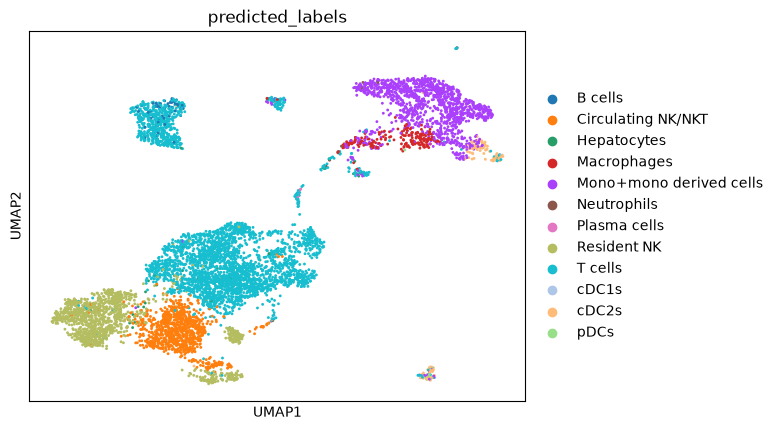

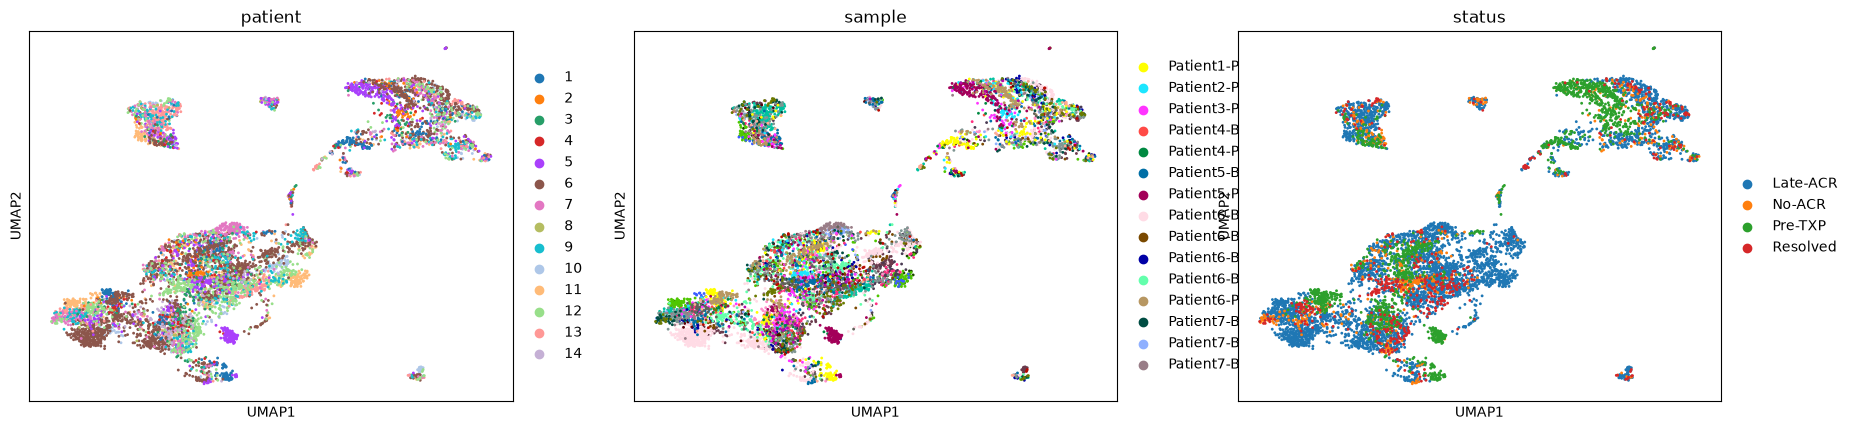

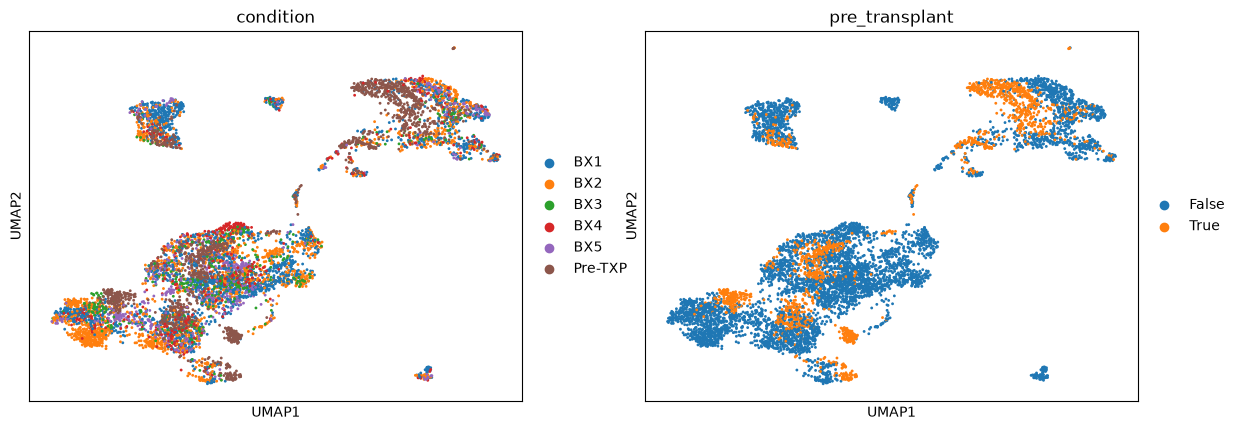

In [6]:
sc.pl.umap(
  mdata['gex'],
  color=["predicted_labels"],
)

sc.pl.umap(
  mdata['gex'],
  color=["patient", "sample", "status"],
)

sc.pl.umap(
  mdata['gex'],
  color=["condition", "pre_transplant"],
)

... storing 'gex:sample' as categorical
... storing 'gex:patient' as categorical
... storing 'gex:condition' as categorical
... storing 'gex:status' as categorical
... storing 'tcr:receptor_type' as categorical
... storing 'tcr:receptor_subtype' as categorical
... storing 'tcr:chain_pairing' as categorical
... storing 'tcr:sample' as categorical
... storing 'tcr:patient' as categorical
... storing 'tcr:condition' as categorical
... storing 'tcr:status' as categorical
... storing 'bcr:receptor_type' as categorical
... storing 'bcr:receptor_subtype' as categorical
... storing 'bcr:chain_pairing' as categorical
... storing 'bcr:sample' as categorical
... storing 'bcr:patient' as categorical
... storing 'bcr:condition' as categorical
... storing 'bcr:status' as categorical


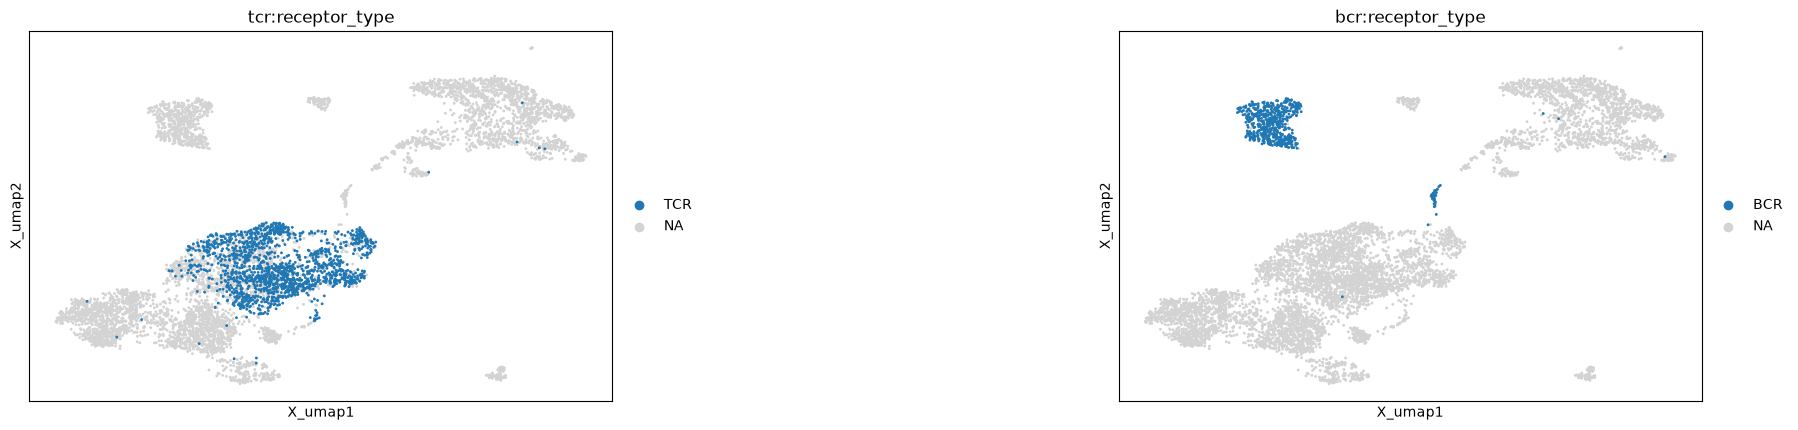

In [7]:
mu.pl.embedding(
  mdata,
  basis="gex:umap",
  color=["tcr:receptor_type", "bcr:receptor_type"],
  ncols=3,
  wspace=0.7,
)

In [8]:
mdata["gex"].obs["predicted_labels"].value_counts()

predicted_labels
T cells                    3314
Mono+mono derived cells    1280
Resident NK                1216
Circulating NK/NKT          922
Macrophages                 216
cDC2s                       123
B cells                      56
Hepatocytes                  41
pDCs                         10
Neutrophils                   9
Plasma cells                  6
cDC1s                         1
Name: count, dtype: int64

In [9]:
mdata["tcr"].obs["chain_pairing"].value_counts()

chain_pairing
single pair    2332
Name: count, dtype: int64

In [10]:
counts = pd.concat({
    "n_T": mdata["tcr"].obs.groupby(["status", "sample"], observed=True).size(),
    "n_B": mdata["bcr"].obs.groupby(["status", "sample"], observed=True).size(),
}, axis=1).fillna(0).astype(int)

counts

n_T   n_B
status   sample                     
Late-ACR Patient10-BX1     197    56
         Patient11-BX1      69   721
         Patient11-BX2     238   151
         Patient11-BX3      68    40
         Patient12-BX1     171    49
         Patient12-BX2      99    42
         Patient13-BX1     143   275
         Patient14-BX1      42    36
         Patient6-BX2      229    35
         Patient6-BX3       60    12
         Patient6-BX4       54    25
         Patient6-BX5       90     6
         Patient7-BX3       76    16
         Patient7-BX4       96    27
         Patient8-BX2       22    13
         Patient9-BX1      135   102
No-ACR   Patient4-BX2       13    12
         Patient5-BX1      112    76
         Patient7-BX2       23    39
Pre-TXP  Patient1-Pre-TXP   31    26
         Patient2-Pre-TXP   42    24
         Patient3-Pre-TXP   29    34
         Patient4-Pre-TXP    7    15
         Patient5-Pre-TXP   15   106
         Patient6-Pre-TXP   38    41
Resolved Patient12-BX3      98     9
         Patient12-BX4      42     4
         Patient12-BX5      53    72
         Patient13-BX2      23  1049
         Patient14-BX4      17     9

In [11]:
per_status = counts.groupby("status").agg(
    n_samples=("n_T", "size"),
    T_mean=("n_T", "mean"),
    B_mean=("n_B", "mean"),
).round(1)

per_status


,n_samples,T_mean,B_mean
status,,,
Late-ACR,16,111.8,100.4
No-ACR,3,49.3,42.3
Pre-TXP,6,27.0,41.0
Resolved,5,46.6,228.6


In [12]:
ir.pp.ir_dist(mdata, airr_mod="tcr")
ir.tl.define_clonotypes(mdata, airr_mod="tcr", receptor_arms="all", dual_ir="primary_only")
mdata

MuData object with n_obs × n_vars = 10521 × 4829
  3 modalities
    gex:	7194 × 4829
      obs:	'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'sample', 'patient', 'condition', 'status', 'pre_transplant', 'predicted_labels', 'over_clustering', 'majority_voting', 'conf_score'
      uns:	'log1p', 'pca', 'neighbors', 'umap', 'over_clustering', 'predicted_labels_colors', 'patient_colors', 'sample_colors', 'status_colors', 'condition_colors', 'pre_transplant_colors', 'tcr:receptor_type_colors', 'bcr:receptor_type_colors'
      obsm:	'X_pca', 'X_umap'
      varm:	'PCs'
      layers:	None, 'counts'
      obsp:	'distances', 'connectivities'
    tcr:	2332 × 0
      obs:	'receptor_type', 'receptor_subtype', 'chain_pairing', 'sample', 'patient', 'condition', 'status', 'pre_transplant', 'clone_id', 'clone_id_size'
      uns:	'ir_dist_nt_identity', 'clone_id'
      obsm:	'airr', 'chain_indices'
    bcr:	3122 × 0
      obs:	'receptor_type', 'receptor_subtype', 'chain_pairing', 'sample', 'patient', 'condition', 'status', 'pre_transplant'
      obsm:	'airr', 'chain_indices'

In [13]:
obs = mdata['tcr'].obs
n_clonotypes = obs['clone_id'].unique().shape[0]
max_clonotype = obs['clone_id_size'].max().item()

print(f"Number of clonotypes: {n_clonotypes}")
print(f"Largest clonotype: {max_clonotype}")

Number of clonotypes: 1726
Largest clonotype: 31


In [14]:
ir.pp.ir_dist(
  mdata,
  airr_mod="tcr",
  metric="tcrdist",
  sequence="aa",
  cutoff=15,
)

ir.tl.define_clonotype_clusters(mdata, airr_mod="tcr", sequence="aa", metric="tcrdist", receptor_arms="all", dual_ir="any")

ir.tl.clonotype_network(mdata, airr_mod="tcr", min_cells=3, sequence="aa", metric="tcrdist")

... storing 'gex:sample' as categorical
... storing 'gex:patient' as categorical
... storing 'gex:condition' as categorical
... storing 'gex:status' as categorical
... storing 'tcr:receptor_type' as categorical
... storing 'tcr:receptor_subtype' as categorical
... storing 'tcr:chain_pairing' as categorical
... storing 'tcr:sample' as categorical
... storing 'tcr:patient' as categorical
... storing 'tcr:condition' as categorical
... storing 'tcr:status' as categorical
... storing 'bcr:receptor_type' as categorical
... storing 'bcr:receptor_subtype' as categorical
... storing 'bcr:chain_pairing' as categorical
... storing 'bcr:sample' as categorical
... storing 'bcr:patient' as categorical
... storing 'bcr:condition' as categorical
... storing 'bcr:status' as categorical
... storing 'tcr:clone_id' as categorical
... storing 'tcr:cc_aa_tcrdist' as categorical
... storing 'receptor_type' as categorical
... storing 'receptor_subtype' as categorical
... storing 'chain_pairing' as categorical

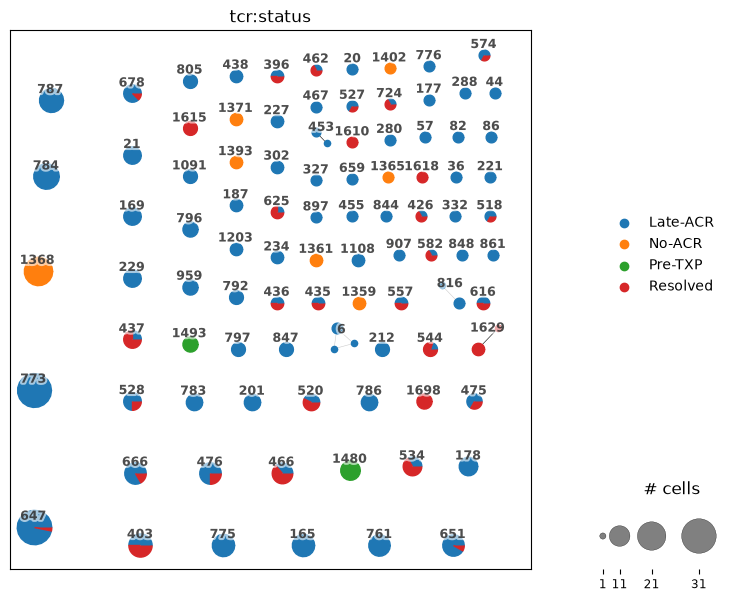

In [15]:
_ = ir.pl.clonotype_network(mdata, airr_mod="tcr", color="tcr:status", base_size=20, label_fontsize=9, panel_size=(7, 7))

In [16]:
ir.tl.clonal_expansion(mdata, airr_mod="tcr")
mdata

MuData object with n_obs × n_vars = 10521 × 4829
  3 modalities
    gex:	7194 × 4829
      obs:	'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'sample', 'patient', 'condition', 'status', 'pre_transplant', 'predicted_labels', 'over_clustering', 'majority_voting', 'conf_score'
      uns:	'log1p', 'pca', 'neighbors', 'umap', 'over_clustering', 'predicted_labels_colors', 'patient_colors', 'sample_colors', 'status_colors', 'condition_colors', 'pre_transplant_colors', 'tcr:receptor_type_colors', 'bcr:receptor_type_colors'
      obsm:	'X_pca', 'X_umap'
      varm:	'PCs'
      layers:	None, 'counts'
      obsp:	'distances', 'connectivities'
    tcr:	2332 × 0
      obs:	'receptor_type', 'receptor_subtype', 'chain_pairing', 'sample', 'patient', 'condition', 'status', 'pre_transplant', 'clone_id', 'clone_id_size', 'cc_aa_tcrdist', 'cc_aa_tcrdist_size', 'clonal_expansion'
      uns:	'ir_dist_nt_identity', 'clone_id', 'ir_dist_aa_tcrdist', 'cc_aa_tcrdist', 'clonotype_network'
      obsm:	'airr', 'chain_indices', 'X_clonotype_network'
    bcr:	3122 × 0
      obs:	'receptor_type', 'receptor_subtype', 'chain_pairing', 'sample', 'patient', 'condition', 'status', 'pre_transplant'
      obsm:	'airr', 'chain_indices'

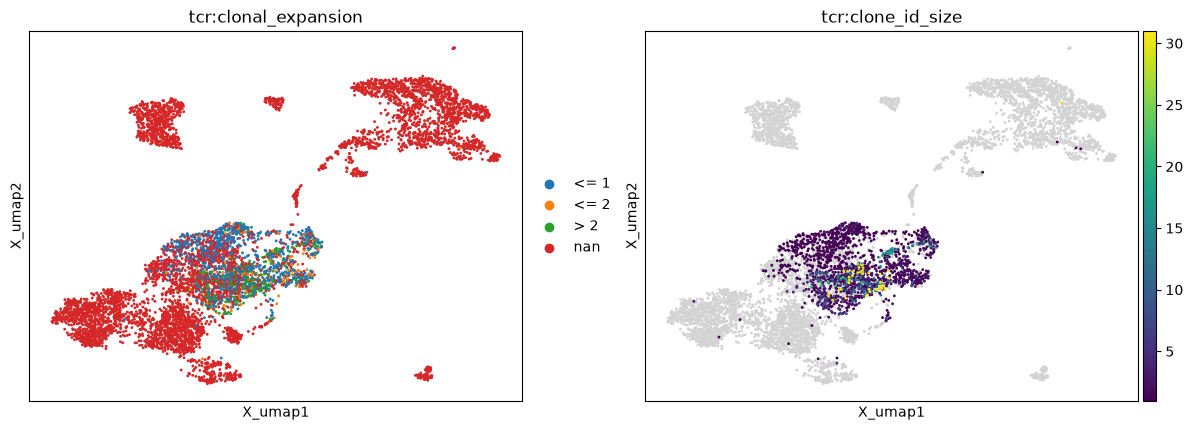

In [17]:
mu.pl.embedding(mdata, basis="gex:umap", color=["tcr:clonal_expansion", "tcr:clone_id_size"])

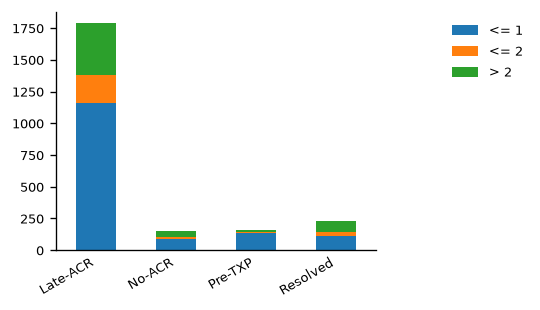

In [25]:
_ = ir.pl.clonal_expansion(mdata, airr_mod="tcr", target_col="clone_id", groupby="tcr:status", breakpoints=(1, 2), normalize=False)

In [19]:
diversity = ir.tl.alpha_diversity(mdata, "tcr:status", airr_mod="tcr", inplace=False)

diversity

,0
Late-ACR,0.964063
No-ACR,0.925071
Pre-TXP,0.974504
Resolved,0.962470


In [20]:
ir.tl.clonotype_convergence(mdata, airr_mod="tcr", key_coarse="cc_aa_tcrdist", key_fine="clone_id")
mdata

MuData object with n_obs × n_vars = 10521 × 4829
  3 modalities
    gex:	7194 × 4829
      obs:	'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'sample', 'patient', 'condition', 'status', 'pre_transplant', 'predicted_labels', 'over_clustering', 'majority_voting', 'conf_score'
      uns:	'log1p', 'pca', 'neighbors', 'umap', 'over_clustering', 'predicted_labels_colors', 'patient_colors', 'sample_colors', 'status_colors', 'condition_colors', 'pre_transplant_colors', 'tcr:receptor_type_colors', 'bcr:receptor_type_colors', 'tcr:clonal_expansion_colors'
      obsm:	'X_pca', 'X_umap'
      varm:	'PCs'
      layers:	None, 'counts'
      obsp:	'distances', 'connectivities'
    tcr:	2332 × 0
      obs:	'receptor_type', 'receptor_subtype', 'chain_pairing', 'sample', 'patient', 'condition', 'status', 'pre_transplant', 'clone_id', 'clone_id_size', 'cc_aa_tcrdist', 'cc_aa_tcrdist_size', 'clonal_expansion', 'is_convergent'
      uns:	'ir_dist_nt_identity', 'clone_id', 'ir_dist_aa_tcrdist', 'cc_aa_tcrdist', 'clonotype_network'
      obsm:	'airr', 'chain_indices', 'X_clonotype_network'
    bcr:	3122 × 0
      obs:	'receptor_type', 'receptor_subtype', 'chain_pairing', 'sample', 'patient', 'condition', 'status', 'pre_transplant'
      obsm:	'airr', 'chain_indices'

In [21]:
obs = mdata['tcr'].obs
obs = obs[obs['is_convergent'] == 'convergent']

convergent_clonotypes = int(obs['clone_id'].nunique())
print(f"Convergent clonotypes: {convergent_clonotypes}")

obs['status'].value_counts()

Convergent clonotypes: 15


status
Late-ACR    14
Resolved     5
Pre-TXP      3
No-ACR       1
Name: count, dtype: int64

In [22]:
obs = mdata["tcr"].obs.copy()
obs["is_expanded"] = obs["clonal_expansion"] == "> 2"

pd.concat({
    "n":    obs.groupby("status", observed=True)["is_expanded"].value_counts(),
    "prop": obs.groupby("status", observed=True)["is_expanded"].value_counts(normalize=True).round(3),
}, axis=1)

n   prop
status   is_expanded             
Late-ACR False        1378  0.770
         True          411  0.230
No-ACR   False         105  0.709
         True           43  0.291
Pre-TXP  False         146  0.901
         True           16  0.099
Resolved False         142  0.609
         True           91  0.391

In [23]:
mdata["gex"].obs["predicted_labels"].value_counts()

predicted_labels
T cells                    3314
Mono+mono derived cells    1280
Resident NK                1216
Circulating NK/NKT          922
Macrophages                 216
cDC2s                       123
B cells                      56
Hepatocytes                  41
pDCs                         10
Neutrophils                   9
Plasma cells                  6
cDC1s                         1
Name: count, dtype: int64